# 1. Разведочный анализ данных

Цель — описать набор до построения модели: состав и целостность, форматы выгрузки, длительности и поведение, возраст, качество сигнала, спектры.

**Правило ноутбука.** Все групповые сравнения здесь описательные. Признаки для модели выбираются по литературе (список в разделе 1.10), а не по различиям, увиденным на этих графиках: иначе выбор признаков уже использовал бы метки всего набора, и оценка качества стала бы оптимистичной.

Вся обработка — в модулях `src/`; ноутбук только вызывает их и показывает результат. Время выполнения — около двух минут.

In [1]:
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "results" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config, dataset, diagnostics, features, preprocessing, viz

# Channels with too few retained windows have NaN spectra by design.
warnings.filterwarnings("ignore", message="All-NaN slice encountered")
warnings.filterwarnings("ignore", message="Mean of empty slice")
viz.apply_style()
pd.set_option("display.precision", 2)
COHORTS = list(config.GROUPS)
cfg = preprocessing.PreprocessingConfig()

## 1.1 Состав и целостность

`dataset.scan_dataset` читает заголовки и цифровые отсчёты всех EDF, находит побитовые копии и объединяет связанные ими ID в независимые группы `split_group` — единицу всех разбиений train/test.

In [2]:
registry, links, subjects = dataset.scan_dataset(config.DATA_DIR)
ok = registry[registry["status"] == "ok"]

summary = registry.groupby("group").agg(
    испытуемых=("subject_id", "nunique"),
    файлов=("relpath", "size"),
    непустых=("status", lambda s: (s == "ok").sum()),
).reindex(COHORTS)
summary["независимых групп"] = subjects.groupby("group")["split_group"].nunique().reindex(COHORTS)
summary

,испытуемых,файлов,непустых,независимых групп
group,,,,
Норма,67,402,402,67
ПТСР,25,150,150,24
Соматоформные,74,444,439,67


In [3]:
print("Пустые файлы:", registry.loc[registry["status"] != "ok", "relpath"].tolist())
print("Заголовок n_records = -1:", int((ok["n_records_header"] == -1).sum()), "файлов, читаются по размеру файла")
same = links["subject_a"] == links["subject_b"]
print(f"Связей по совпадающему содержимому: {len(links)} (между разными ID: {(~same).sum()}, внутри ID: {same.sum()})")
links[["relpath_a", "relpath_b"]]

Пустые файлы: ['Соматоформные/XCFU5/T-1.edf', 'Соматоформные/XCFU5/T-2.edf', 'Соматоформные/XCFU5/T-3.edf', 'Соматоформные/XCFU5/T-4.edf', 'Соматоформные/XCFU5/T-5.edf']
Заголовок n_records = -1: 9 файлов, читаются по размеру файла
Связей по совпадающему содержимому: 27 (между разными ID: 22, внутри ID: 5)


,relpath_a,relpath_b
0,ПТСР/DFGH/T-П.edf,ПТСР/WSXD/T-1.edf
1,Соматоформные/DFGH8/T-2.edf,Соматоформные/DFGH8/T-3.edf
2,Соматоформные/DIKL0/T-1.edf,Соматоформные/GHRD3/T-П.edf
3,Соматоформные/DIKL0/T-2.edf,Соматоформные/GHRD3/T-1.edf
4,Соматоформные/DIKL0/T-3.edf,Соматоформные/GHRD3/T-2.edf
5,Соматоформные/DIKL0/T-4.edf,Соматоформные/GHRD3/T-3.edf
6,Соматоформные/KGBT5/T-4.edf,Соматоформные/KGBT5/T-5.edf
7,Соматоформные/KRTM8/T-5.edf,Соматоформные/PYVB0/T-5.edf
8,Соматоформные/LDPR3/T-3.edf,Соматоформные/ZILO6/T-4.edf
9,Соматоформные/LDPR3/T-4.edf,Соматоформные/ZILO6/T-5.edf


Среди копий есть файлы, чьё содержимое встречается и как покой, и как проба таблицы (`condition_conflict`). Для них истинное условие записи неизвестно. У пары `DIKL0`/`GHRD3` одни и те же записи лежат под номерами проб, сдвинутыми на одну. Заранее принятое правило: файл с конфликтом условий не используется для признаков своего условия и для реактивности «задача − покой».

In [4]:
registry.loc[registry["condition_conflict"], ["relpath", "condition", "duplicate_set"]].sort_values("duplicate_set")

,relpath,condition,duplicate_set
414,ПТСР/DFGH/T-П.edf,rest,419
541,ПТСР/WSXD/T-1.edf,task,419
607,Соматоформные/DIKL0/T-1.edf,task,604
666,Соматоформные/GHRD3/T-П.edf,rest,604
725,Соматоформные/LDPR3/T-5.edf,task,717
972,Соматоформные/ZILO6/T-П.edf,rest,717
882,Соматоформные/TMVN4/T-П.edf,rest,852
863,Соматоформные/SIGO3/T-5.edf,task,852
887,Соматоформные/TMVN4/T-5.edf,task,852
948,Соматоформные/XYKT7/T-П.edf,rest,927


Экспорт формата B дополняет последний неполный секундный блок EDF нулями на всех каналах (`edge_constant_s` — длительность застывшего сигнала на краях записи). Без обработки последнее окно у ПТСР содержало бы ступеньку «сигнал → 0», добавляющую широкополосную мощность, — артефакт, связанный с меткой. Предобработка обрезает такие края до фильтрации; внутри записей застывших участков нет.

In [5]:
ok.assign(padded=ok["edge_constant_s"] >= 0.1).groupby(["group", "export_family"]).agg(
    файлов=("relpath", "size"), с_застывшим_краем=("padded", "sum"), медиана_с=("edge_constant_s", "median"),
    максимум_с=("edge_constant_s", "max"), внутри_записи_с=("interior_constant_s", "max"))

файлов  с_застывшим_краем  медиана_с  максимум_с  \
group         export_family                                                     
Норма         A                 120                  0       0.00        0.00   
              B                  12                 12       0.69        0.89   
              C                 270                  0       0.00        0.00   
ПТСР          B                 150                138       0.52        0.98   
Соматоформные A                 439                  0       0.00        0.00   

                             внутри_записи_с  
group         export_family                   
Норма         A                          0.0  
              B                          0.0  
              C                          0.0  
ПТСР          B                          0.0  
Соматоформные A                          0.0

## 1.2 Форматы выгрузки

Шаг квантования `Δ = (P_max − P_min)/(D_max − D_min)` вычисляется для каждого канала каждого файла (во всех файлах он одинаков для шести каналов). Формат — диагностическая переменная: в модель он не подаётся, но по нему проверяется, не различает ли модель способ экспорта вместо физиологии.

In [6]:
family = ok.groupby("subject_key")["export_family"].agg(lambda s: "".join(sorted(set(s))))
subjects["export_family"] = family.reindex(subjects.index)
fam_table = pd.crosstab(subjects["group"], subjects["export_family"]).reindex(COHORTS)
fam_table.columns = [f"формат {c}" for c in fam_table.columns]
fam_table

,формат A,формат B,формат C
group,,,
Норма,20,2,45
ПТСР,0,25,0
Соматоформные,74,0,0


In [7]:
(ok.groupby("export_family")
   .agg(шаг_мкВ_мин=("quant_step_uv", "min"), шаг_мкВ_макс=("quant_step_uv", "max"),
        диапазон_макс_мкВ=("physical_max", "max"), частоты_Гц=("sfreq", lambda s: sorted(s.unique())),
        доля_BS50=("notch_50", "mean"), файлов=("relpath", "size")))

,шаг_мкВ_мин,шаг_мкВ_макс,диапазон_макс_мкВ,частоты_Гц,доля_BS50,файлов
export_family,,,,,,
A,1.00e+00,1.00,32767.0,[125.0],1.0,559
B,6.10e-02,0.06,2000.0,[125.0],1.0,162
C,2.70e-03,0.02,871.0,"[123.0, 124.0, 125.0, 126.0, 127.0]",0.0,270


Насколько формат выдаёт метку: AUC правила «формат B → ПТСР» на паре ПТСР/контроль, без какого-либо анализа сигнала.

In [8]:
from sklearn.metrics import roc_auc_score

pair = subjects[subjects["group"].isin([config.GROUP_CONTROL, config.GROUP_PTSD])]
no_c = pair[pair["export_family"] != "C"]
print(f"AUC правила «формат B»: вся норма {roc_auc_score(pair['label'], pair['export_family'] == 'B'):.3f}; "
      f"только нормы A и B {roc_auc_score(no_c['label'], no_c['export_family'] == 'B'):.3f}")

AUC правила «формат B»: вся норма 0.985; только нормы A и B 0.955


## 1.3 Частота дискретизации и длительность записей

In [9]:
pd.crosstab(ok["group"], ok["sfreq"]).reindex(COHORTS)

sfreq,123.0,124.0,125.0,126.0,127.0
group,,,,,
Норма,47,52,194,58,51
ПТСР,0,0,150,0,0
Соматоформные,0,0,439,0,0


In [10]:
ok.groupby(["condition", "group"])["active_duration_s"].describe()[["count", "min", "25%", "50%", "75%", "max"]]

count    min    25%    50%    75%     max
condition group                                                   
rest      Норма           67.0  60.00  61.00  61.00  61.00   65.00
          ПТСР            25.0  34.51  60.55  61.32  61.51   65.50
          Соматоформные   74.0  32.00  60.00  61.00  63.00  121.00
task      Норма          335.0  17.00  36.00  41.00  52.00  133.00
          ПТСР           125.0   7.66  44.66  54.55  73.54  122.52
          Соматоформные  365.0   1.00  35.00  43.00  52.00  142.00

Длительность записи пробы задумана как время решения таблицы Шульте (так её трактуют и эксперты). Используется `active_duration_s` — длительность без застывших краёв. Номер пробы содержателен: первая проба включает освоение задания.

Проверка перед сравнением: у всех испытуемых формата C пять проб имеют одинаковую длительность, в остальных форматах — ни у кого. Поэтому для формата C длительность не может считаться временем решения, и поведение сравнивается отдельно по форматам.

In [11]:
per_subject_task = ok[ok["condition"] == "task"].groupby(["group", "export_family", "subject_key"])["active_duration_s"]
templated = per_subject_task.nunique().eq(1).groupby(level=[0, 1]).agg(["sum", "size"])
templated.columns = ["испытуемых с одинаковой длительностью 5 проб", "всего"]
c_task = ok[(ok["export_family"] == "C") & (ok["condition"] == "task")]
print("Формат C, длительности проб (с):", c_task.groupby("subject_key")["active_duration_s"].first().value_counts().sort_index().to_dict())
templated

Формат C, длительности проб (с): {34.0: 8, 36.0: 5, 41.0: 14, 52.0: 7, 53.0: 11}


испытуемых с одинаковой длительностью 5 проб  \
group         export_family                                                 
Норма         A                                                         0   
              B                                                         0   
              C                                                        45   
ПТСР          B                                                         0   
Соматоформные A                                                         0   

                             всего  
group         export_family         
Норма         A                 20  
              B                  2  
              C                 45  
ПТСР          B                 25  
Соматоформные A                 73

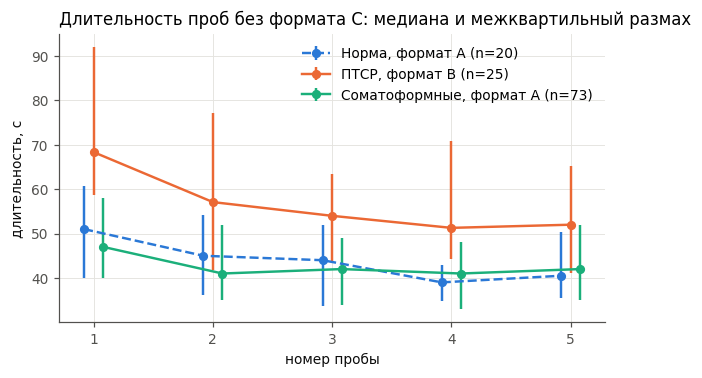

trial                            1      2      3      4      5
group         export_family                                   
Норма         A              51.00  45.00  44.00  39.00  40.50
              B              37.57  33.64  31.72  40.72  35.84
              C              41.00  41.00  41.00  41.00  41.00
ПТСР          B              68.35  57.10  54.00  51.29  52.00
Соматоформные A              47.00  41.00  42.00  41.00  42.00

In [12]:
task = ok[ok["condition"] == "task"]
strata_beh = [(config.GROUP_CONTROL, "A", "--"), (config.GROUP_PTSD, "B", "-"), (config.GROUP_SOMATOFORM, "A", "-")]
fig, ax = plt.subplots(figsize=(6.4, 3.4))
for i, (cohort, fam, style) in enumerate(strata_beh):
    d = task[(task["group"] == cohort) & (task["export_family"] == fam)]
    q = d.groupby("trial")["active_duration_s"].quantile([0.25, 0.5, 0.75]).unstack()
    x = q.index + (i - 1) * 0.08
    ax.errorbar(x, q[0.5], yerr=[q[0.5] - q[0.25], q[0.75] - q[0.5]], color=viz.COHORT_COLORS[cohort], ls=style,
                marker="o", ms=5, capsize=0, lw=1.6, label=f"{cohort}, формат {fam} (n={d['subject_key'].nunique()})")
ax.set_xticks(range(1, 6))
ax.set_xlabel("номер пробы")
ax.set_ylabel("длительность, с")
ax.set_title("Длительность проб без формата C: медиана и межквартильный размах", loc="left")
ax.legend()
plt.show()
task.pivot_table(index=["group", "export_family"], columns="trial", values="active_duration_s", aggfunc="median")

## 1.4 Возраст и пол

Возраст известен только в контроле (из имени папки). По ТЗ: контроль — мужчины 18–55 лет, ПТСР — мужчины 18–45 лет (возраст отдельного испытуемого неизвестен), соматоформные — 18–45 лет, оба пола. Группа «нормальное старение» (65+) есть в закрытом тесте.

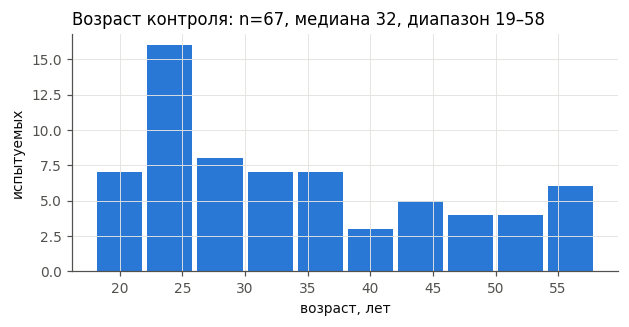

export_family,A,B,C
age,,,
18–29,15,0,16
30–45,3,2,17
46–64,2,0,12


In [13]:
ages = subjects.loc[subjects["group"] == config.GROUP_CONTROL, "age"]
fig, ax = plt.subplots(figsize=(6.4, 2.8))
ax.hist(ages, bins=np.arange(18, 62, 4), color=viz.COHORT_COLORS[config.GROUP_CONTROL], rwidth=0.9)
ax.set_xlabel("возраст, лет")
ax.set_ylabel("испытуемых")
ax.set_title(f"Возраст контроля: n={ages.size}, медиана {ages.median():.0f}, диапазон {ages.min():.0f}–{ages.max():.0f}", loc="left")
plt.show()
controls = subjects[subjects["group"] == config.GROUP_CONTROL]
pd.crosstab(pd.cut(controls["age"], [18, 29, 45, 64], labels=["18–29", "30–45", "46–64"]), controls["export_family"])

## 1.5 Качество: отбраковка окон

Окна 4 с с шагом 2 с; флаги ставятся отдельно для каждого канала каждого окна с одинаковыми для всех порогами (`PreprocessingConfig`): плоский сигнал, насыщение (≥ 3 отсчёта подряд на границе цифрового диапазона), размах > 400 мкВ, выброс дисперсии внутри канала записи, выпадение сигнала (все каналы застыли). Насыщение и выпадение расширяются защитным интервалом 0.5 с, перекрывающим распространение разрыва фильтрами.

In [14]:
qc = preprocessing.rejection_table(registry, cfg).merge(
    registry[["relpath", "group", "condition", "export_family", "subject_key"]], on="relpath")
qc["frac_good"] = qc["n_good"] / qc["n_windows"].replace(0, np.nan)
flag_cols = ["frac_good", "frac_flat", "frac_rail", "frac_amplitude", "frac_variance", "frac_dropout"]
qc.groupby(["condition", "group"])[flag_cols].mean()

frac_good  frac_flat  frac_rail  frac_amplitude  \
condition group                                                            
rest      Норма               0.98        0.0   0.00e+00        6.34e-03   
          ПТСР                0.89        0.0   3.22e-02        7.81e-02   
          Соматоформные       0.77        0.0   2.22e-03        2.10e-01   
task      Норма               0.94        0.0   0.00e+00        3.79e-02   
          ПТСР                0.87        0.0   3.71e-02        9.27e-02   
          Соматоформные       0.74        0.0   1.33e-03        2.29e-01   

                         frac_variance  frac_dropout  
condition group                                       
rest      Норма                   0.02           0.0  
          ПТСР                    0.10           0.0  
          Соматоформные           0.17           0.0  
task      Норма                   0.05           0.0  
          ПТСР                    0.11           0.0  
          Соматоформные           0.17           0.0

In [15]:
qc.pivot_table(index=["condition", "group"], columns="channel", values="frac_good")[list(config.CHANNELS)]

channel                    O1    T3   Fp1   Fp2    T4    O2
condition group                                            
rest      Норма          0.97  0.97  0.99  0.99  0.99  0.99
          ПТСР           0.88  0.88  0.86  0.90  0.91  0.90
          Соматоформные  0.80  0.70  0.80  0.82  0.68  0.80
task      Норма          0.96  0.91  0.99  0.99  0.84  0.93
          ПТСР           0.90  0.82  0.87  0.91  0.87  0.87
          Соматоформные  0.79  0.67  0.78  0.79  0.67  0.77

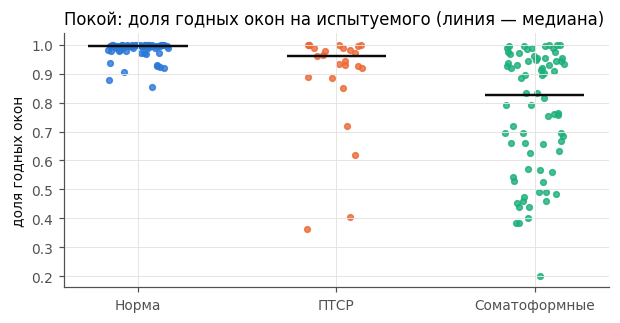

export_family
A    0.95
B    0.98
C    1.00
Name: норма, покой: доля годных окон, dtype: float64

In [16]:
rest_qc = qc[qc["condition"] == "rest"]
per_subject = rest_qc.groupby(["group", "subject_key"])["frac_good"].mean()
fig, ax = plt.subplots(figsize=(6.4, 3.0))
for i, cohort in enumerate(COHORTS):
    v = per_subject.loc[cohort].to_numpy()
    jitter = np.random.default_rng(0).uniform(-0.15, 0.15, v.size)
    ax.scatter(i + jitter, v, s=14, color=viz.COHORT_COLORS[cohort], alpha=0.8)
    ax.hlines(np.median(v), i - 0.25, i + 0.25, color="#0b0b0b", lw=1.6)
ax.set_xticks(range(3), COHORTS)
ax.set_ylabel("доля годных окон")
ax.set_title("Покой: доля годных окон на испытуемого (линия — медиана)", loc="left")
plt.show()
rest_qc[rest_qc["group"] == config.GROUP_CONTROL].groupby("export_family")["frac_good"].mean().rename("норма, покой: доля годных окон")

## 1.6 Примеры сигналов

Первые 10 с покоя (глаза закрыты) после ресэмплинга к 125 Гц и ФНЧ 40 Гц, без отбраковки. Для каждой группы показан испытуемый с медианной долей годных окон — типичная, а не лучшая запись. Норма показана отдельно для форматов A и C. Внизу — испорченная запись, на которой проверяется отбраковка.

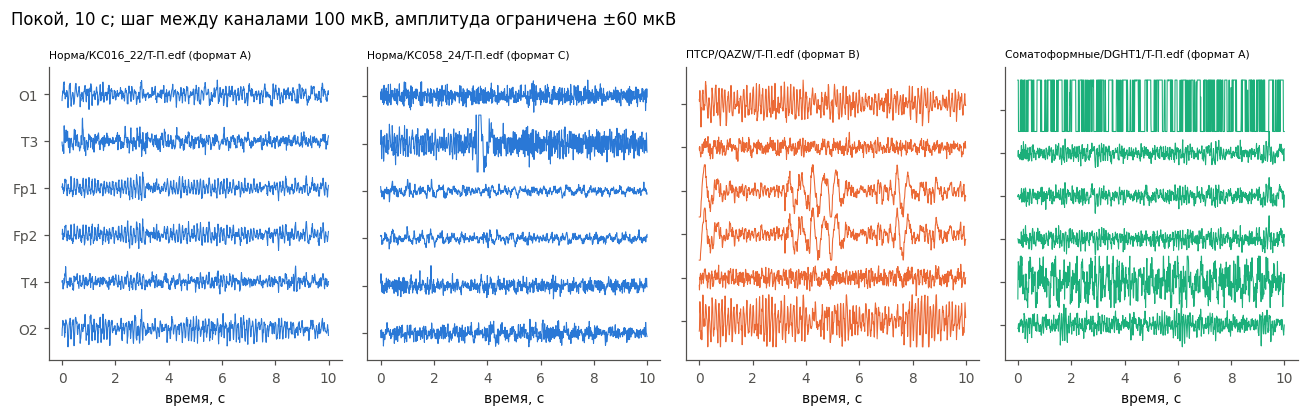

In [17]:
def conditioned(relpath: str) -> np.ndarray:
    rec = dataset.load_record(config.DATA_DIR / relpath)
    x = preprocessing.resample(rec.data, rec.sfreq, cfg.target_sfreq)
    return preprocessing.lowpass(x, cfg.target_sfreq, cfg.lowpass_hz)  # shape: (6, n_times), uV

def typical_rest(cohort: str, fam: str) -> str:
    rec_quality = rest_qc[(rest_qc["group"] == cohort) & (rest_qc["export_family"] == fam)].groupby("relpath")["frac_good"].mean()
    return (rec_quality - rec_quality.median()).abs().sort_values(kind="stable").index[0]

panels = [(config.GROUP_CONTROL, "A"), (config.GROUP_CONTROL, "C"), (config.GROUP_PTSD, "B"), (config.GROUP_SOMATOFORM, "A")]
fig, axes = plt.subplots(1, 4, figsize=(12, 3.8))
for ax, (cohort, fam) in zip(axes, panels):
    relpath = typical_rest(cohort, fam)
    viz.plot_traces(ax, np.clip(conditioned(relpath)[:, : 10 * 125], -60, 60), cfg.target_sfreq,
                    spacing_uv=100, color=viz.COHORT_COLORS[cohort])
    ax.set_title(f"{relpath} (формат {fam})", loc="left", fontsize=7)
    ax.label_outer()
fig.suptitle("Покой, 10 с; шаг между каналами 100 мкВ, амплитуда ограничена ±60 мкВ", x=0.01, ha="left")
plt.tight_layout()
plt.show()

СКО по каналам, мкВ: {'O1': 24, 'T3': 937, 'Fp1': 22, 'Fp2': 24, 'T4': 3296, 'O2': 33}


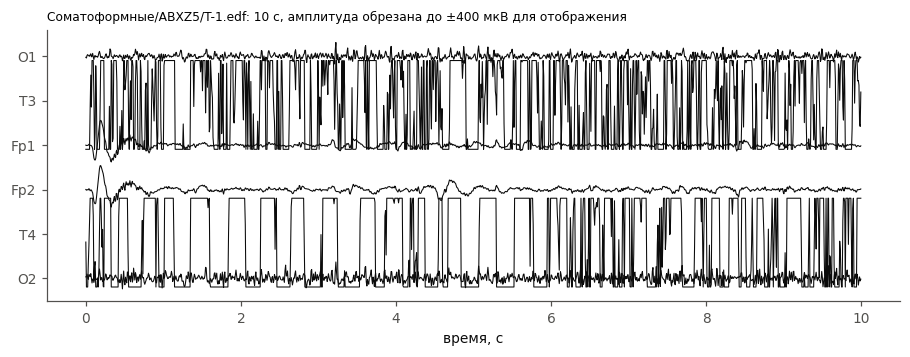

In [18]:
bad = "Соматоформные/ABXZ5/T-1.edf"
x = conditioned(bad)
print("СКО по каналам, мкВ:", {ch: round(float(s)) for ch, s in zip(config.CHANNELS, x.std(axis=1))})
fig, ax = plt.subplots(figsize=(10, 3.2))
viz.plot_traces(ax, np.clip(x[:, : 10 * 125], -400, 400), cfg.target_sfreq, spacing_uv=400)
ax.set_title(f"{bad}: 10 с, амплитуда обрезана до ±400 мкВ для отображения", loc="left", fontsize=8)
plt.show()

## 1.7 Спектр по форматам выгрузки (диагностика, без ФНЧ)

Чтобы увидеть область выше 40 Гц, спектры здесь считаются без нашего ФНЧ. Спектр записи — среднее логарифмов периодограмм годных окон (окно Ханна 4 с, разрешение 0.25 Гц) с поправкой смещения γ/ln 10; смещение не зависит от числа окон (см. `src/features.py`). Для каждой записи берётся медиана по шести каналам. Цвет — когорта, панель — формат. Пунктир — уровень белого шума квантования при Δ = 1 мкВ.

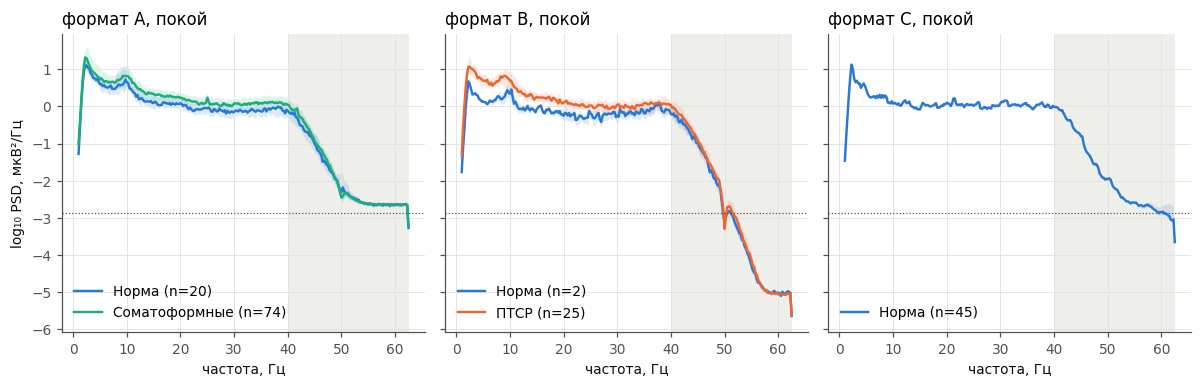

In [19]:
spec_diag = features.compute_spectra(registry, preprocessing.PreprocessingConfig(lowpass_hz=None))
meta = registry.set_index("relpath").loc[list(spec_diag.relpaths)]
per_record = np.nanmedian(spec_diag.spectra, axis=1)  # shape: (n_files, n_freqs), uV^2/Hz
f = spec_diag.freqs
keep = f >= 1.0

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=True)
for ax, fam in zip(axes, ["A", "B", "C"]):
    for cohort in COHORTS:
        sel = ((meta["export_family"] == fam) & (meta["group"] == cohort) & (meta["condition"] == "rest")).to_numpy()
        if sel.sum():
            viz.plot_median_spectra(ax, f[keep], per_record[sel][:, keep], cohort, viz.COHORT_COLORS[cohort])
    viz.shade_unused_band(ax, 40.0, 62.5)
    ax.axhline(np.log10(1 / 12 / 62.5), color=viz.TEXT_MUTED, lw=0.8, ls=":")
    ax.set_title(f"формат {fam}, покой", loc="left")
    ax.legend(loc="lower left")
    ax.label_outer()
plt.tight_layout()
plt.show()

## 1.8 Типичные черты ЭЭГ по форматам

Две проверяемые черты ЭЭГ с общим ушным референтом:

1. **Межканальная корреляция.** Все каналы делят референтный электрод, а объёмное проведение распространяет активность коры, поэтому симметричные пары положительно коррелируют без сдвига (Fp1–Fp2 — через глазную активность, O1–O2 — через затылочную альфу).
2. **Затылочная альфа в покое с закрытыми глазами** (эффект Бергера): пик 8–13 Гц на O1/O2 над соседними частотами. Выраженность = максимум log₁₀ PSD в 8–13 Гц минус среднее по 5–7 и 14–17 Гц; 0.4 означает пик в 2.5 раза выше окружения. На плоском шумном спектре мера около 0.2: максимум по 21 частотному отсчёту шума всегда выше среднего.

Отсутствие этих черт показывает, что запись отличается от типичной ЭЭГ, но само по себе не доказывает, что сигнал — не ЭЭГ. Дополнительно — отношение амплитуды T3 к медиане остальных каналов: референт на левом ухе, T3 ближе всех к нему и ожидается ниже 1.

Функции — в `src/diagnostics.py`; это проверки правдоподобия сигнала, в модель они не входят.

In [20]:
plaus_all = diagnostics.plausibility_table(registry, cfg).merge(
    registry[["relpath", "group", "export_family", "subject_key", "condition", "subject_id"]], on="relpath")
plaus = plaus_all[plaus_all["condition"] == "rest"]
pair_cols = ["O1-O2", "Fp1-Fp2", "T3-T4"]
keys = ["group", "export_family"]
table = plaus.groupby(keys)[pair_cols + ["alpha_prominence_occ", "t3_rms_ratio"]].median()
table["доля с альфа-пиком > 0.4"] = plaus.groupby(keys)["alpha_prominence_occ"].apply(lambda v: (v > 0.4).mean())
table["записей"] = plaus.groupby(keys).size()
table

O1-O2  Fp1-Fp2  T3-T4  alpha_prominence_occ  \
group         export_family                                                   
Норма         A              5.03e-01     0.84   0.11                  0.91   
              B              6.12e-01     0.80   0.15                  1.15   
              C             -8.97e-04     0.02   0.01                  0.19   
ПТСР          B              6.01e-01     0.89   0.21                  0.83   
Соматоформные A              5.33e-01     0.79   0.17                  0.74   

                             t3_rms_ratio  доля с альфа-пиком > 0.4  записей  
group         export_family                                                   
Норма         A                      0.81                      0.80       20  
              B                      0.81                      0.50        2  
              C                      2.79                      0.00       45  
ПТСР          B                      0.84                      0.88       25  
Соматоформные A                      0.96                      0.81       74

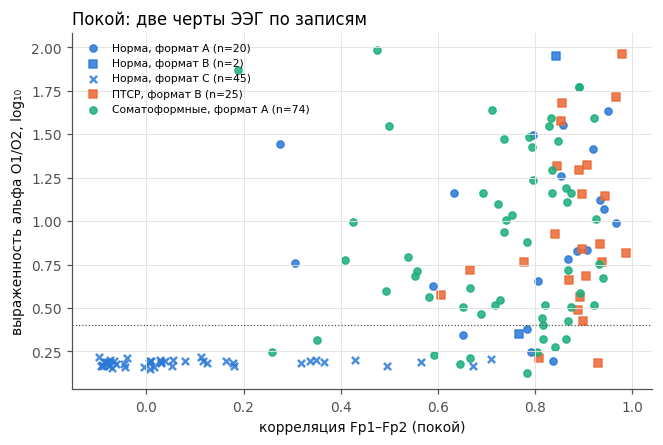

In [21]:
fig, ax = plt.subplots(figsize=(6.8, 4.2))
markers = {"A": "o", "B": "s", "C": "x"}
for cohort in COHORTS:
    for fam, marker in markers.items():
        d = plaus[(plaus["group"] == cohort) & (plaus["export_family"] == fam)]
        if len(d):
            ax.scatter(d["Fp1-Fp2"], d["alpha_prominence_occ"], s=22, marker=marker, color=viz.COHORT_COLORS[cohort],
                       alpha=0.85, label=f"{cohort}, формат {fam} (n={len(d)})")
ax.axhline(0.4, color=viz.TEXT_MUTED, lw=0.8, ls=":")
ax.set_xlabel("корреляция Fp1–Fp2 (покой)")
ax.set_ylabel("выраженность альфа O1/O2, log₁₀")
ax.set_title("Покой: две черты ЭЭГ по записям", loc="left")
ax.legend(fontsize=7, loc="upper left")
plt.show()

**Гипотеза «покой записан с открытыми глазами».** Она объяснила бы отсутствие альфы, но для корреляции предсказывает обратное: при открытых глазах моргания и саккады синхронно видны на Fp1 и Fp2, и корреляция Fp1–Fp2 должна быть высокой, как в пробах таблиц у всех остальных групп. Ниже — те же черты в пробах таблиц (глаза открыты по протоколу).

In [22]:
plaus_all[plaus_all["condition"] == "task"].groupby(keys)[pair_cols + ["t3_rms_ratio"]].median()

O1-O2  Fp1-Fp2     T3-T4  t3_rms_ratio
group         export_family                                           
Норма         A              4.63e-01     0.87  1.35e-01          0.79
              B              4.96e-01     0.92  1.30e-01          1.07
              C             -6.61e-03     0.10  9.25e-04          2.78
ПТСР          B              6.03e-01     0.88  2.41e-01          0.82
Соматоформные A              5.78e-01     0.82  2.16e-01          0.98

In [23]:
low_alpha = plaus[(plaus["group"] == config.GROUP_CONTROL) & (plaus["alpha_prominence_occ"] < 0.3)]
print(f"Норма, покой, выраженность альфа < 0.3: {len(low_alpha)} записей; по форматам:", low_alpha["export_family"].value_counts().to_dict())
low_alpha[low_alpha["export_family"] != "C"][["subject_id", "export_family", "alpha_prominence_occ", "Fp1-Fp2", "O1-O2"]]

Норма, покой, выраженность альфа < 0.3: 47 записей; по форматам: {'C': 45, 'A': 2}


,subject_id,export_family,alpha_prominence_occ,Fp1-Fp2,O1-O2
108,КС054_26,A,0.19,0.84,0.28
390,КС148_23,A,0.25,0.79,0.07


## 1.9 Спектры покоя и задачи по отведениям (полоса анализа 2–40 Гц)

Основной конвейер: ресэмплинг, ФНЧ 40 Гц, отбраковка. Линия — медиана по испытуемым, полоса — межквартильный размах. Для задачи спектр испытуемого — медиана по его пробам, чтобы каждый человек входил один раз. Файлы с конфликтом условий исключены. Норма показана отдельно для форматов A и C (стиль линии).

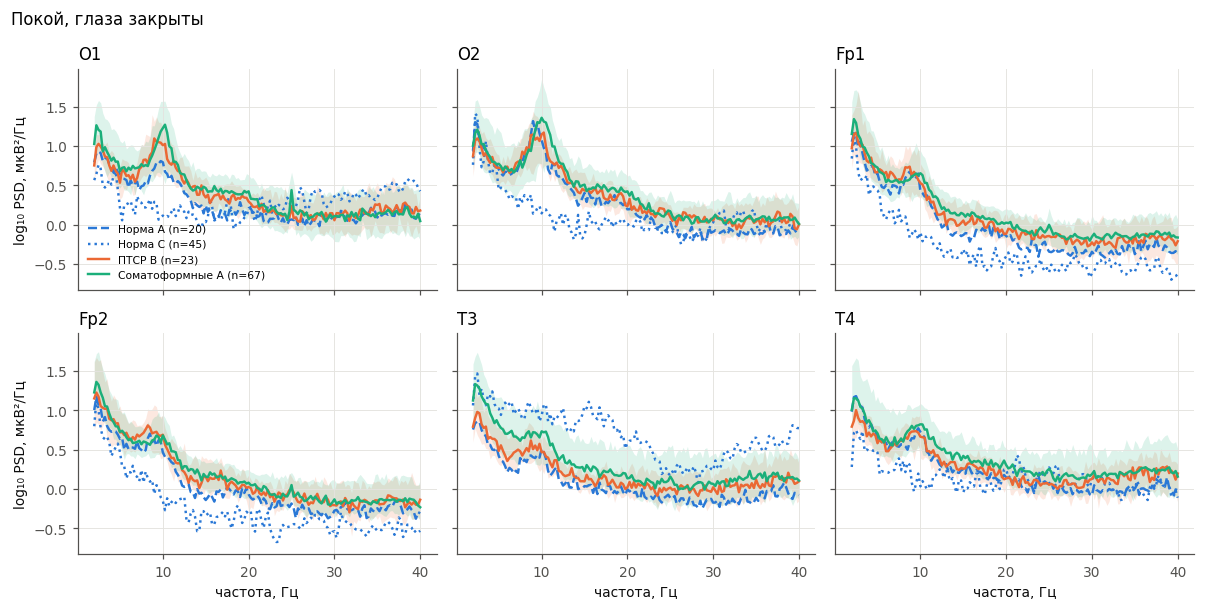

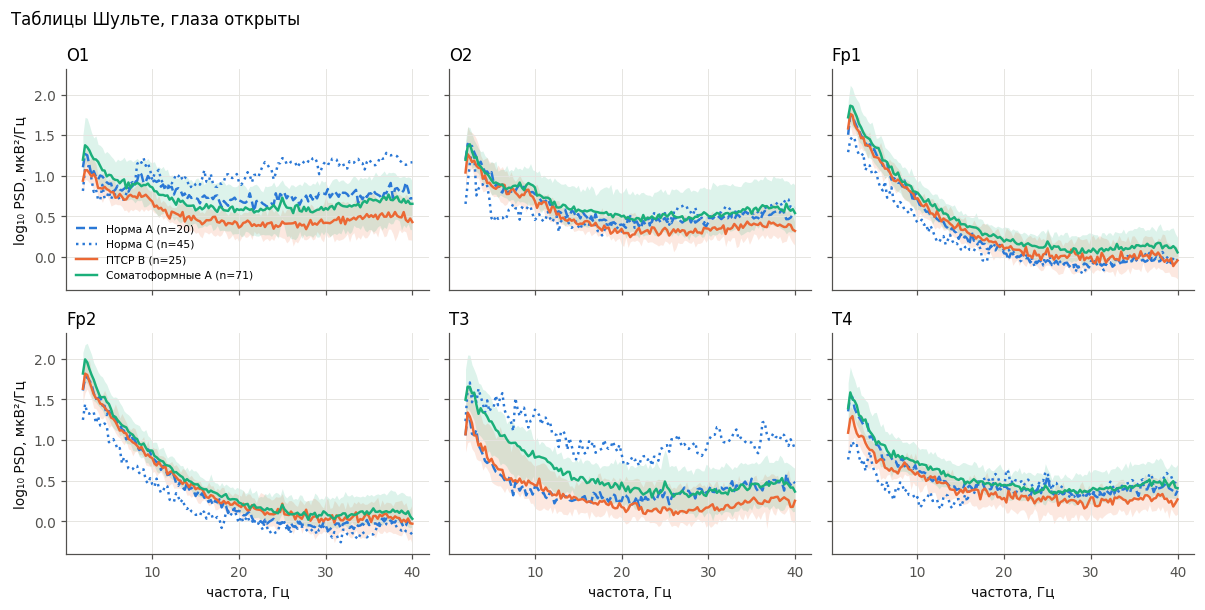

In [24]:
spec = features.compute_spectra(registry, cfg)
meta = registry.set_index("relpath").loc[list(spec.relpaths)].reset_index()
f = spec.freqs
band = (f >= 2.0) & (f <= 40.0)

def subject_spectra(condition: str) -> tuple[np.ndarray, pd.DataFrame]:
    # median over the subject's usable records -> shape (n_subjects, n_channels, n_freqs)
    idx = meta.index[(meta["condition"] == condition) & ~meta["condition_conflict"]]
    groups = meta.loc[idx].groupby("subject_key").groups
    keys_ = sorted(groups)
    stacked = np.stack([np.nanmedian(spec.spectra[list(groups[k])], axis=0) for k in keys_])
    return stacked, subjects.loc[keys_, ["group", "export_family"]]

strata = [(config.GROUP_CONTROL, "A", "--"), (config.GROUP_CONTROL, "C", ":"),
          (config.GROUP_PTSD, "B", "-"), (config.GROUP_SOMATOFORM, "A", "-")]
for condition, title in [("rest", "Покой, глаза закрыты"), ("task", "Таблицы Шульте, глаза открыты")]:
    s, info = subject_spectra(condition)
    fig, axes = plt.subplots(2, 3, figsize=(11, 5.6), sharex=True, sharey=True)
    for ax, ch_idx in zip(axes.ravel(), [0, 5, 2, 3, 1, 4]):
        for cohort, fam, style in strata:
            sel = ((info["group"] == cohort) & (info["export_family"] == fam)).to_numpy() & np.isfinite(s[:, ch_idx, band]).all(axis=1)
            viz.plot_median_spectra(ax, f[band], s[sel, ch_idx][:, band], f"{cohort} {fam}", viz.COHORT_COLORS[cohort],
                                    style, band=style == "-")
        ax.set_title(config.CHANNELS[ch_idx], loc="left")
        ax.label_outer()
    axes[0, 0].legend(loc="lower left", fontsize=7)
    fig.suptitle(title, x=0.01, ha="left")
    plt.tight_layout()
    plt.show()

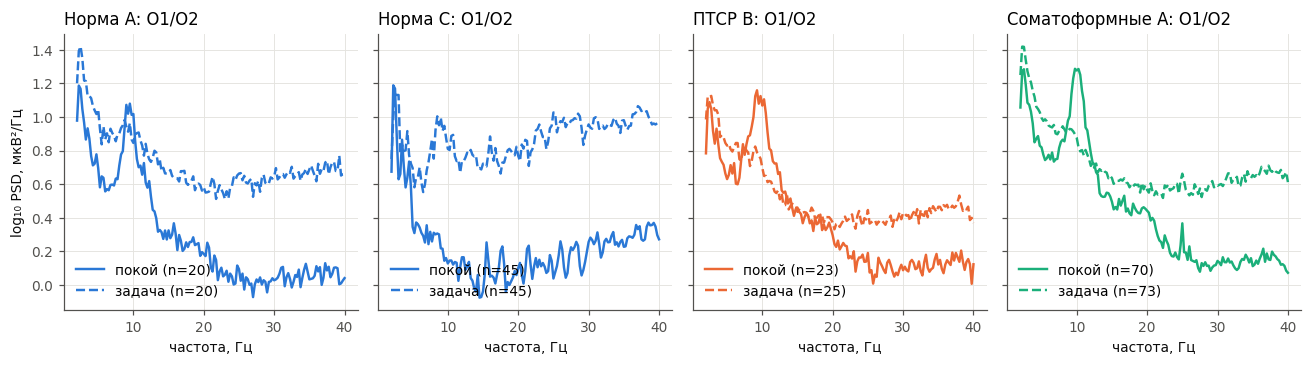

In [25]:
rest_s, rest_info = subject_spectra("rest")
task_s, task_info = subject_spectra("task")
occ = [config.CHANNELS.index("O1"), config.CHANNELS.index("O2")]
fig, axes = plt.subplots(1, 4, figsize=(12, 3.4), sharey=True)
for ax, (cohort, fam, _) in zip(axes, strata):
    for s, info, style, label in [(rest_s, rest_info, "-", "покой"), (task_s, task_info, "--", "задача")]:
        sel = ((info["group"] == cohort) & (info["export_family"] == fam)).to_numpy()
        occipital = np.nanmean(s[sel][:, occ], axis=1)  # shape: (n_subjects, n_freqs)
        viz.plot_median_spectra(ax, f[band], occipital[:, band], label, viz.COHORT_COLORS[cohort], style, band=False)
    ax.set_title(f"{cohort} {fam}: O1/O2", loc="left")
    ax.legend(loc="lower left")
    ax.label_outer()
plt.tight_layout()
plt.show()

## 1.10 Выводы

**Состав и целостность.** 166 ID → 158 независимых групп (8 пар ID связаны общими записями, ни одна группа не смешивает когорты). 5 пустых файлов (`XCFU5`, пробы). 11 файлов с конфликтом условий: у 5 испытуемых файл покоя побитово совпадает с пробой таблицы; такие файлы исключаются из признаков своего условия. Экспорт формата B дополняет конец записи нулями — края обрезаются до фильтрации.

**Формат выгрузки почти полностью задаёт метку.** Все 25 ПТСР — формат B; из 67 норм в формате B только 2. Правило «формат B → ПТСР» без анализа сигнала даёт AUC 0.985 на паре ПТСР/контроль (0.955, если оставить только нормы форматов A и B). Исключение формата C эту проблему не решает. Поэтому высокий общий AUC сам по себе не подтверждает физиологический маркер; результаты показываются по форматам, а признаки проверяются на устойчивость к известным различиям экспорта.

**Формат C (45 из 67 норм) отличается от типичной ЭЭГ.** Симметричные каналы не коррелируют ни в покое, ни в пробах таблиц (медианы r ≈ 0.00–0.10 против 0.46–0.92 у Fp1–Fp2 и O1–O2 в форматах A и B); затылочного альфа-пика в покое нет (выраженность ≈ 0.2 — уровень плоского шумного спектра); амплитуда T3 в ~2.8 раза выше остальных каналов (в форматах A и B — 0.8–1.0, как и ожидается у отведения рядом с референтом на левом ухе); длительности пяти проб у каждого испытуемого одинаковы (34, 36, 41, 52 или 53 с), покой — ровно 61 с. Чтение подтверждено независимым ридером (MNE) на всех 270 файлах формата C. Гипотеза «покой записан с открытыми глазами» объясняет отсутствие альфы, но не отсутствие корреляции Fp1–Fp2, которая при открытых глазах высока. «46 записей без альфа-пика» из консультации — это по сути формат C: при пороге выраженности 0.3 отбираются все 45 норм формата C и 1–2 нормы формата A (`КС054_26`, `КС148_23`; точное число зависит от способа оценки спектра). Причина отличий по данным не устанавливается.

**Возраст переплетён с форматом.** Из 14 норм старше 45 лет 12 записаны в формате C. Метрики по возрастным подгруппам контроля и предсказание возраста по признакам нужно показывать и внутри формата.

**Поведение.** Без формата C: медиана первой пробы — ПТСР 68 с, норма формата A 51 с, соматоформные 47 с; у ПТСР длительность снижается к пятой пробе. Длительность — сильный кандидат-признак и одновременно конфаундер; в формате C она не является временем решения. Модель оценивается с поведением и без него, поведение — по форматам.

**Качество.** Доля годных окон в покое: норма 98%, ПТСР 89%, соматоформные 77%. Насыщение встречается почти только в формате B (граница ±2000 мкВ). Качество связано с когортой и в модель не подаётся.

**Спектры.** В форматах A и B спектры покоя имеют затылочный пик около 10 Гц и спад мощности с частотой; выше 40 Гц форма зависит от формата (у B на два порядка ниже) и в признаки не входит.

### Гипотезы о признаках (из литературы, не из этих графиков)

| Семейство | Отведения, условие | Обоснование |
| --- | --- | --- |
| Индивидуальная частота альфа-пика и его выраженность | O1, O2; покой | Kovacevic et al., 2025: смещение и ослабление альфа при ПТСР |
| Апериодическая экспонента и смещение спектра | все; покой, задача | Donoghue et al., 2020: разделение ритмов и фона 1/f |
| Относительная мощность тета, альфа, бета | все; покой, задача | классические спектральные маркеры, инвариантны к общему усилению |
| Реактивность альфа «задача / покой» | O1, O2 | подавление альфа при открывании глаз и нагрузке; не классическая ERD |
| Межполушарная асимметрия альфа | O2–O1 (Fp с оговоркой о глазах) | референт на левом ухе смещает T3–T4, поэтому височная асимметрия напрямую не интерпретируется |
| Поведение: длительность проб и её динамика | — | оценивается отдельно: с поведением и без, по форматам |

**Конфаундеры для раздела 4:** формат выгрузки, качество записи, возраст (только в контроле, переплетён с форматом), пол (соматоформные — оба пола), длительность записи.